---
**GUIA DE LABORATORIO 5 - Estadistica Descriptiva**  
**Nombre:** Roberto Roly Copa Mamani  
**Materia:** Machine Learning - INF 672

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# --- paleta INF672 (para que los gráficos combinen con el documento) ---
INDIGO, PURPLE, CORAL, INK, GREY = "#4F46E5", "#7E22CE", "#F43F5E", "#111827", "#6B7280"
plt.rcParams.update({
    "axes.edgecolor": "#D1D5DB", "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.7, "axes.axisbelow":
True,
    "figure.dpi": 110,
})

iris = load_iris()
df = pd.DataFrame(iris.data, columns=["sep_largo", "sep_ancho", "pet_largo", "pet_ancho"])
print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (150, 4)


,sep_largo,sep_ancho,pet_largo,pet_ancho
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


El dataset contiene 150 registros y 4 características numéricas relacionadas con las dimensiones de sépalos y pétalos

In [2]:
col = df["pet_largo"]
print("media   :", round(col.mean(), 3))
print("mediana :", round(col.median(), 3))
print("moda    :", col.mode().tolist())

media   : 3.758
mediana : 4.35
moda    : [1.4, 1.5]


La media y la mediana son diferentes. Esto me indica que los datos no están distribuidos de forma completamente simétrica. Los valores pequeños de algunas flores hacen que la media disminuya

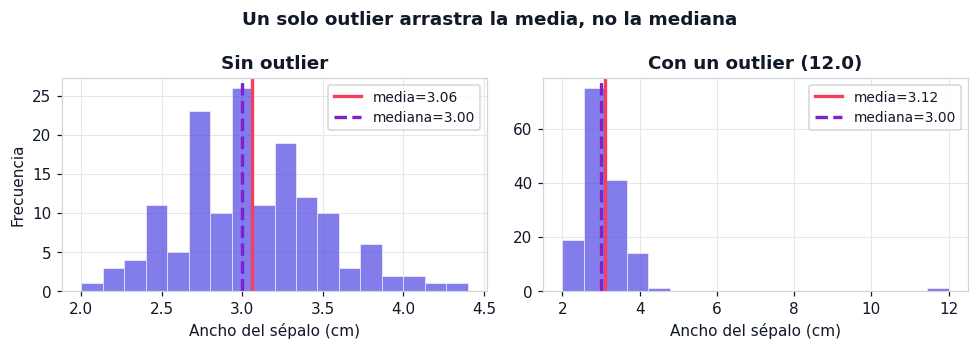

In [3]:
base = df["sep_ancho"].values
conout = np.append(base, 12.0)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, data, titulo in [(axes[0], base, "Sin outlier"),
                         (axes[1], conout, "Con un outlier (12.0)")]:
    ax.hist(data, bins=18, color=INDIGO, alpha=0.7, edgecolor="white", linewidth=0.5)
    ax.axvline(data.mean(),   color=CORAL,  lw=2.2, label=f"media={data.mean():.2f}")
    ax.axvline(np.median(data), color=PURPLE, lw=2.2, ls="--",
label=f"mediana={np.median(data):.2f}")
    ax.set_title(titulo); ax.set_xlabel("Ancho del sépalo (cm)"); ax.legend(fontsize=9)
axes[0].set_ylabel("Frecuencia")
fig.suptitle("Un solo outlier arrastra la media, no la mediana", fontweight="bold")
plt.tight_layout(); plt.show()

Al agregar un dato extremadamente grande, observé que la media cambia de manera visible, mientras que la mediana prácticamente se mantiene. Por ello, cuando existen outliers, la mediana puede representar mejor el centro de los datos

In [4]:
print("desv. σ  :", round(col.std(ddof=0), 3))

# Resumen de las cuatro características a la vez:
resumen = pd.DataFrame({
    "media":   df.mean().round(2),
    "mediana": df.median().round(2),
    "desv_σ":  df.std(ddof=0).round(2),
    "min":     df.min().round(2),
    "max":     df.max().round(2),
})
resumen

desv. σ  : 1.759


,media,mediana,desv_σ,min,max
sep_largo,5.84,5.80,0.83,4.3,7.9
sep_ancho,3.06,3.00,0.43,2.0,4.4
pet_largo,3.76,4.35,1.76,1.0,6.9
pet_ancho,1.20,1.30,0.76,0.1,2.5


El largo del pétalo presenta una desviación estándar cercana a 1.76, mientras que el ancho del sépalo tiene aproximadamente 0.43. Esto significa que el largo del pétalo presenta una mayor dispersión

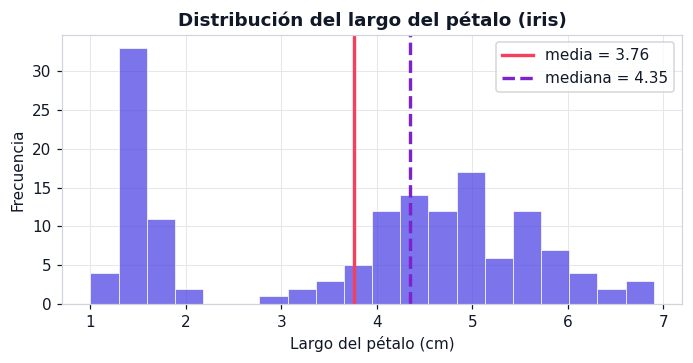

In [7]:
pl = df["pet_largo"].values
plt.figure(figsize=(6.4, 3.4))
plt.hist(pl, bins=20, color=INDIGO, alpha=0.75, edgecolor="white", linewidth=0.6)
plt.axvline(pl.mean(),   color=CORAL,  lw=2.2, label=f"media = {pl.mean():.2f}")
plt.axvline(np.median(pl), color=PURPLE, lw=2.2, ls="--", label=f"mediana = {np.median(pl):.2f}")
plt.xlabel("Largo del pétalo (cm)"); plt.ylabel("Frecuencia")
plt.title("Distribución del largo del pétalo (iris)"); plt.legend()
plt.tight_layout(); plt.show()

En el histograma se observan dos zonas de concentración, por lo que la distribución puede considerarse bimodal. El grupo de pétalos pequeños aparece separado del resto de observaciones. Esto demuestra que una sola medida como la media no siempre describe completamente los datos

In [8]:
df.corr().round(2)

,sep_largo,sep_ancho,pet_largo,pet_ancho
sep_largo,1.00,-0.12,0.87,0.82
sep_ancho,-0.12,1.00,-0.43,-0.37
pet_largo,0.87,-0.43,1.00,0.96
pet_ancho,0.82,-0.37,0.96,1.00


El largo y el ancho del pétalo presentan una correlación positiva muy fuerte de aproximadamente 0.96. Esto significa que, en general, cuando aumenta el largo del pétalo también aumenta su ancho

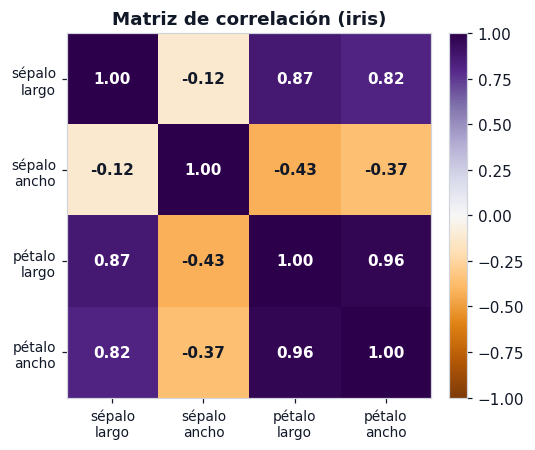

In [9]:
C = df.corr().values
labels = ["sépalo\nlargo", "sépalo\nancho", "pétalo\nlargo", "pétalo\nancho"]
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(C, cmap="PuOr", vmin=-1, vmax=1)
ax.set_xticks(range(4), labels, fontsize=9); ax.set_yticks(range(4), labels, fontsize=9)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(C[i,j]) > 0.55 else INK, fontweight="bold")
ax.set_title("Matriz de correlación (iris)"); ax.grid(False)
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

El mapa de calor permite identificar las correlaciones de manera visual. La relación más fuerte entre variables diferentes corresponde al largo y ancho del pétalo

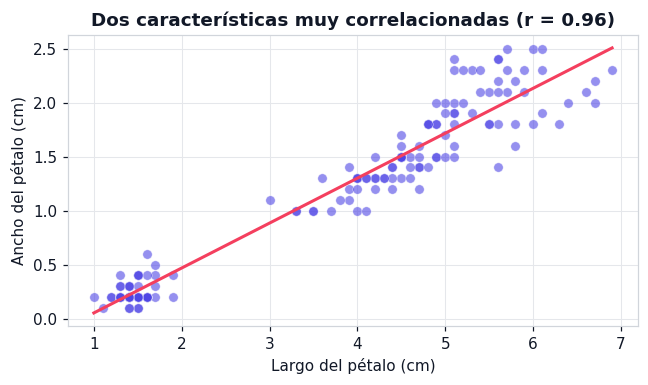

In [10]:
x, y = df["pet_largo"].values, df["pet_ancho"].values
r = np.corrcoef(x, y)[0, 1]
b1, b0 = np.polyfit(x, y, 1)
plt.figure(figsize=(6, 3.6))
plt.scatter(x, y, color=INDIGO, alpha=0.6, edgecolor="white", linewidth=0.4, s=38)
plt.plot([x.min(), x.max()], b0 + b1*np.array([x.min(), x.max()]), color=CORAL, lw=2)
plt.xlabel("Largo del pétalo (cm)"); plt.ylabel("Ancho del pétalo (cm)")
plt.title(f"Dos características muy correlacionadas (r = {r:.2f})")
plt.tight_layout(); plt.show()

El gráfico confirma lo observado en la matriz de correlación. Los puntos siguen una tendencia ascendente bastante definida, por lo que ambas características tienen una relación lineal positiva fuerte

In [11]:
xc, yc = x - x.mean(), y - y.mean()
cos = xc @ yc / (np.linalg.norm(xc) * np.linalg.norm(yc))
print("Pearson (np.corrcoef) :", round(np.corrcoef(x, y)[0, 1], 6))
print("coseno centrado       :", round(float(cos), 6))
print("¿idénticos? ->", np.isclose(np.corrcoef(x, y)[0, 1], cos))

Pearson (np.corrcoef) : 0.962865
coseno centrado       : 0.962865
¿idénticos? -> True


El resultado demuestra numéricamente que la correlación de Pearson puede interpretarse como la similitud coseno entre las variables después de centrar sus valores restando la media

**Conclusión**
Con este laboratorio pude comprobar que antes de entrenar un modelo de Machine Learning es necesario conocer los datos. La media, mediana y desviación estándar permiten resumirlos, mientras que los histogramas muestran su distribución. También comprobé que la correlación ayuda a identificar variables que contienen información muy similar. Estas herramientas permiten tomar mejores decisiones durante el preprocesamiento de los datos